--- LabAnalyzer: Final Clinical Evaluation Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        28

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


--- Confusion Matrix (0=Healthy, 1=CKD) ---
[[52  0]
 [ 0 28]]


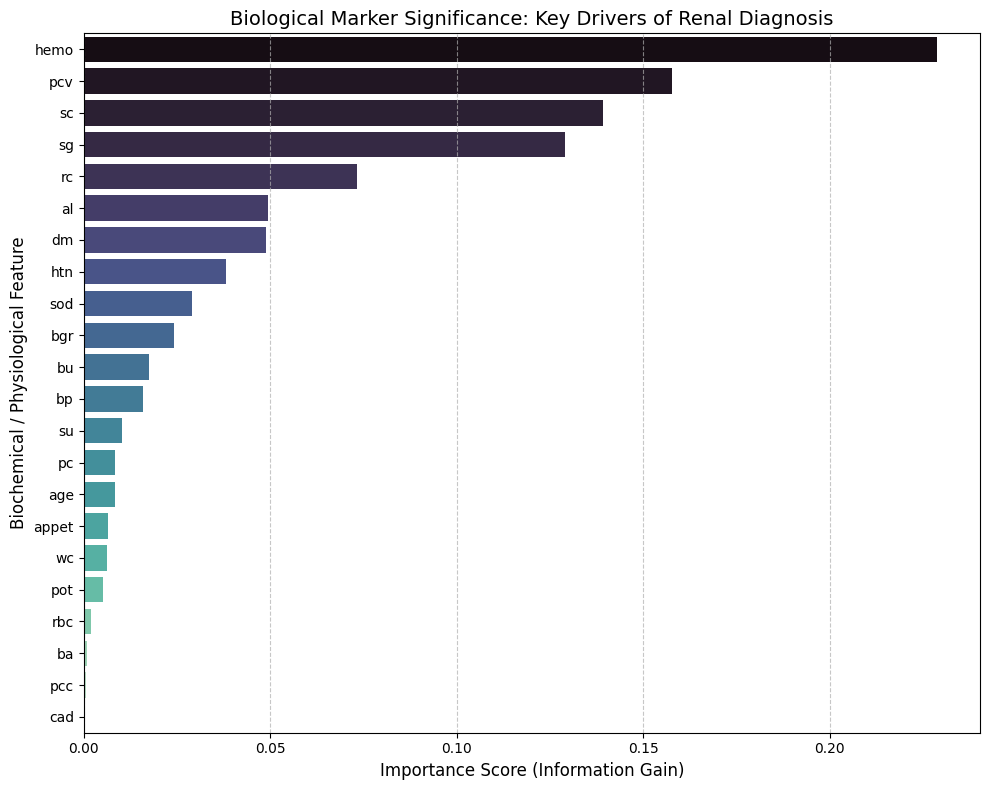

In [2]:
# ---------------------------------------------------------
# LABANALYZER: FINAL OPTIMIZED DIAGNOSTIC MODEL
# ---------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load the pre-processed data
df = pd.read_csv('../data/processed/cleaned_kidney_data.csv')

# 2. Feature Selection (Evicting external symptoms & IDs)
x = df.drop(['id', 'classification', 'ane', 'pe'], axis=1)
y = df['classification']

# 3. Train/Test Split (80/20)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

# 4. Initialize the Optimized Random Forest (Parameters from Grid Search)
production_model = RandomForestClassifier(
    n_estimators=100, 
    criterion='gini', 
    max_depth=None, 
    min_samples_split=10, 
    random_state=42
)

# 5. Train the Model
production_model.fit(x_train, y_train)

# 6. Generate Final Predictions
y_pred = production_model.predict(x_test)

# ---------------------------------------------------------
# REPORTING & VISUALIZATION
# ---------------------------------------------------------

# Print Diagnostic Metrics
print("--- LabAnalyzer: Final Clinical Evaluation Report ---")
print(classification_report(y_test, y_pred))
print("\n--- Confusion Matrix (0=Healthy, 1=CKD) ---")
print(confusion_matrix(y_test, y_pred))

# Map Feature Importances
importances = production_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Biomarker': x.columns, 
    'Information_Gain': importances
}).sort_values(by='Information_Gain', ascending=False)

# Plot the Biological Logic
plt.figure(figsize=(10, 8))
sns.barplot(x='Information_Gain', y='Biomarker', hue='Biomarker', data=feature_importance_df, palette='mako', legend=False)
plt.title('Biological Marker Significance: Key Drivers of Renal Diagnosis', fontsize=14)
plt.xlabel('Importance Score (Information Gain)', fontsize=12)
plt.ylabel('Biochemical / Physiological Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()


plt.show()